# RMSSD Analysis

In [1]:
import os
import sys

import pandas as pd

import matplotlib.pyplot as plt

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../../signal'))

from data_processing import DataProcessing

In [2]:
notebook_dir

'/Users/detraviousjamaribrinkley/Documents/Development/research_labs/roeh_labs/health/closed_loop_wearable_therapies/lamina/notebook_experiments/ans_basics_via_wesad'

In [3]:
base_path = os.path.join(notebook_dir, '..')
base_data_path = DataProcessing.load_base_data_path(base_path)
metrics_folder = os.path.join(base_data_path, 'ecg_to_hr')
metrics_folder

'/Users/detraviousjamaribrinkley/Documents/Development/research_labs/roeh_labs/health/closed_loop_wearable_therapies/lamina/notebook_experiments/ans_basics_via_wesad/../../../data/ecg_to_hr'

In [4]:
rmssd = 'HRV_RMSSD'
labels = {
    'baseline',
    'stress',
    'amusement',
    'meditation'}

In [5]:
data_per_label = {}

print(f"Searching for HRV data files in: {metrics_folder}\n")

for label in labels:
    # Path to the specific label's sub-folder (e.g., .../ecg_to_hr/baseline/)
    label_folder_path = os.path.join(metrics_folder, 'S4', label)
    
    try:
        # Find the first file in the directory that ends with .csv
        csv_filename = next(f for f in os.listdir(label_folder_path) if f.endswith('.csv'))
        
        # Construct the full path to that file
        full_file_path = os.path.join(label_folder_path, csv_filename)
        
        # Load the file into a DataFrame
        df = DataProcessing.load_from_file(data_path=full_file_path, file_type='csv')
        
        # Add the DataFrame to the dictionary with the label as the key
        data_per_label[label] = df
        print(f"Successfully loaded '{label}' data.")
        
    except (FileNotFoundError, StopIteration):
        print(f"Warning: Could not find or load a CSV file for the '{label}' label.")

# You can now access each DataFrame like this:
# if 'baseline' in data_per_label:
#     print("\nPreview of Baseline DataFrame:")
#     print(data_per_label['baseline'].head())

Searching for HRV data files in: /Users/detraviousjamaribrinkley/Documents/Development/research_labs/roeh_labs/health/closed_loop_wearable_therapies/lamina/notebook_experiments/ans_basics_via_wesad/../../../data/ecg_to_hr

Successfully loaded 'stress' data.
Successfully loaded 'amusement' data.
Successfully loaded 'baseline' data.
Successfully loaded 'meditation' data.


In [6]:
baseline_df = data_per_label['baseline']
stress_df = data_per_label['stress']
amusement_df = data_per_label['amusement']
meditation_df = data_per_label['meditation']

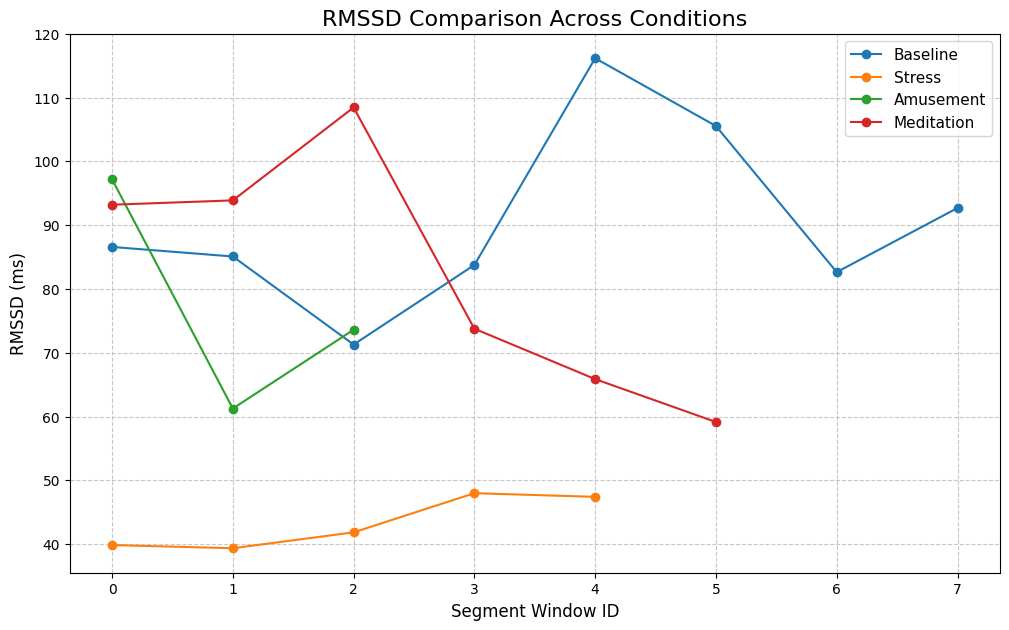

In [7]:
# Create a figure for the plot
plt.figure(figsize=(12, 7))

# Plot each condition with a specific label for the legend
baseline_df[rmssd].plot(marker='o', linestyle='-', label='Baseline')
stress_df[rmssd].plot(marker='o', linestyle='-', label='Stress')
amusement_df[rmssd].plot(marker='o', linestyle='-', label='Amusement')
meditation_df[rmssd].plot(marker='o', linestyle='-', label='Meditation')

# Add enhancements to the plot
plt.title('RMSSD Comparison Across Conditions', fontsize=16)
plt.xlabel('Segment Window ID', fontsize=12)
plt.ylabel('RMSSD (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)

# Display the plot
plt.show()

In total, 17 subjects participated in our study. Due to sensor malfunction, the data of two participants had to be discarded. The remaining 15 subjects had a mean age of 27.5 ± 2.4 years. Twelve subjects were male and the other three subjects were female.
- PAPER: [Introducing WESAD, a Multimodal Dataset for WearableStress and Affect Detection](https://dl.acm.org/doi/epdf/10.1145/3242969.3242985)
- > 26 - 35 range


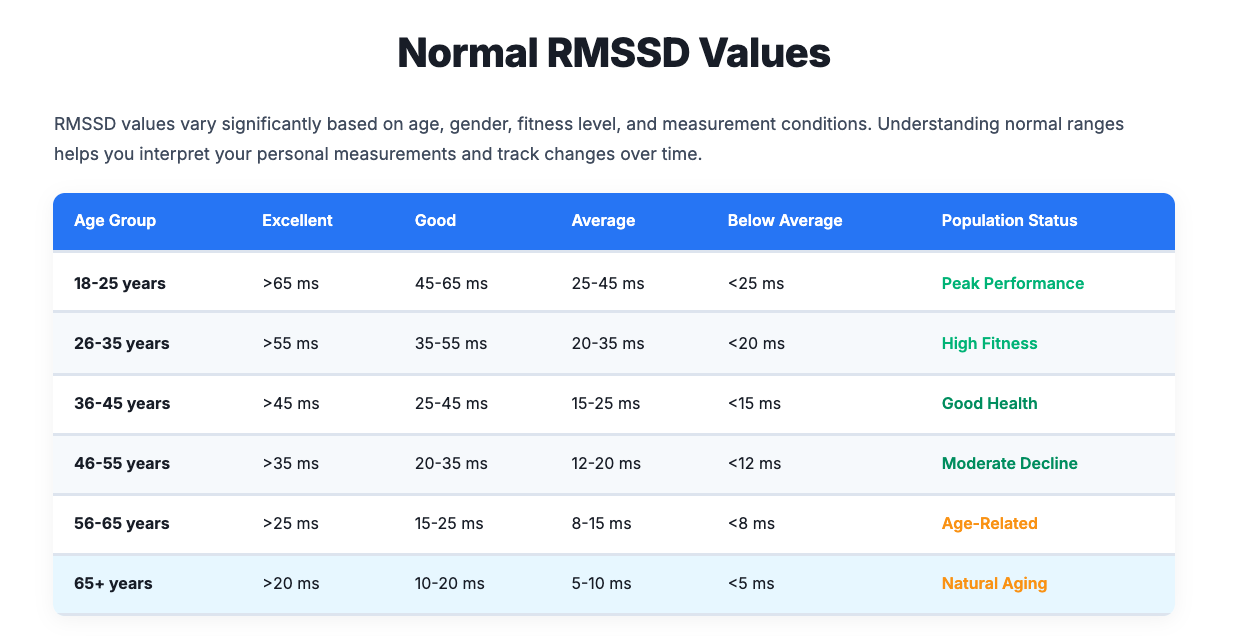
- WEBSITE: [RMSSD Explained by Heart Rate Hero](https://heartratehero.com/RMSSD)